In [8]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Set, Optional

plt.style.use('seaborn-v0_8-darkgrid')

In [9]:
class CascadeSimulator:
    """Класс для моделирования каскадных разрушений в графе."""
    
    def __init__(self, num_nodes: int = 50, num_edges: int = 70, capacity: float = 10.0):
        self.num_nodes = num_nodes
        self.num_edges = num_edges
        self.capacity = capacity
        

        while True:
            self.G = nx.gnm_random_graph(num_nodes, num_edges)
            if nx.is_connected(self.G):
                break
            
        self.base_loads = np.random.randint(5, 10, size=num_nodes).astype(float)
        
    def run_simulation(self, epicenters: List[int]) -> Dict:
        """
        Запускает симуляцию разрушения от заданных эпицентров.
        
        Args:
            epicenters: Список индексов узлов, с которых начинается разрушение.
            
        Returns:
            Словарь с историей разрушения и шагами достижения критериев.
        """
        loads = self.base_loads.copy()
        # Множество активных (неразрушенных) вершин
        active_nodes: Set[int] = set(self.G.nodes())
        
        # Запускаем процесс: устанавливаем критическую нагрузку эпицентрам
        for ep in epicenters:
            loads[ep] = self.capacity 
            
        history_active_count =[len(active_nodes)]
        
        connectivity_step: Optional[int] = None
        destruction_step: Optional[int] = None
        
        step = 0
        
        while True:
            # Находим узлы, которые превысили предел и должны разрушиться на этом шаге
            failing_nodes =[n for n in active_nodes if loads[n] >= self.capacity]
            
            # Если никто больше не ломается — каскад остановился
            if not failing_nodes:
                break
                
            step += 1
            
            # Перераспределение нагрузки (Load Shedding)
            for node in failing_nodes:
                # Находим живых соседей, которые еще не ломаются на этом шаге
                active_neighbors =[
                    nbr for nbr in self.G.neighbors(node) 
                    if nbr in active_nodes and nbr not in failing_nodes
                ]
                
                if active_neighbors:
                    # Нагрузка делится поровну между соседями
                    distributed_load = loads[node] / len(active_neighbors)
                    for nbr in active_neighbors:
                        loads[nbr] += distributed_load
                        
            # Удаляем разрушенные узлы
            for node in failing_nodes:
                active_nodes.remove(node)
                
            # --- Проверка критериев ---
            history_active_count.append(len(active_nodes))
            
            # Создаем подграф из оставшихся узлов для проверки связности
            subgraph = self.G.subgraph(active_nodes)
            
            if len(active_nodes) > 0:
                n_components = nx.number_connected_components(subgraph)
            else:
                n_components = 0
                
            # Критерий связности: граф распался на 2+ части (исключая тривиальный случай пустого графа)
            if connectivity_step is None and (n_components > 1 or n_components == 0):
                connectivity_step = step
                
            # Критерий полного разрушения: 0 активных вершин
            if destruction_step is None and len(active_nodes) == 0:
                destruction_step = step

        return {
            "history": history_active_count,
            "connectivity_step": connectivity_step,
            "destruction_step": destruction_step,
            "total_steps": step
        }

# Инициализируем симулятор
simulator = CascadeSimulator(100, 150)

# Выбираем случайные эпицентры
all_nodes = list(simulator.G.nodes())
np.random.shuffle(all_nodes)

epicenter_1 =[all_nodes[0]]
epicenters_3 = all_nodes[1:4]

# Запуск для 1 эпицентра (Пункт 2)
result_1_epi = simulator.run_simulation(epicenter_1)
print(f"--- Результаты для 1 эпицентра (Узел {epicenter_1[0]}) ---")
print(f"Критерий связности достигнут на шаге: {result_1_epi['connectivity_step']}")
print(f"Критерий полного разрушения достигнут на шаге: {result_1_epi['destruction_step']}")
print(f"Осталось узлов после остановки каскада: {result_1_epi['history'][-1]}\n")

# Запуск для 3 эпицентров (Пункт 3)
result_3_epi = simulator.run_simulation(epicenters_3)
print(f"--- Результаты для 3 эпицентров (Узлы {epicenters_3}) ---")
print(f"Критерий связности достигнут на шаге: {result_3_epi['connectivity_step']}")
print(f"Критерий полного разрушения достигнут на шаге: {result_3_epi['destruction_step']}")
print(f"Осталось узлов после остановки каскада: {result_3_epi['history'][-1]}")

--- Результаты для 1 эпицентра (Узел 42) ---
Критерий связности достигнут на шаге: 4
Критерий полного разрушения достигнут на шаге: None
Осталось узлов после остановки каскада: 1

--- Результаты для 3 эпицентров (Узлы [79, 45, 92]) ---
Критерий связности достигнут на шаге: 1
Критерий полного разрушения достигнут на шаге: None
Осталось узлов после остановки каскада: 3


Визуализация для 1 эпицентра:


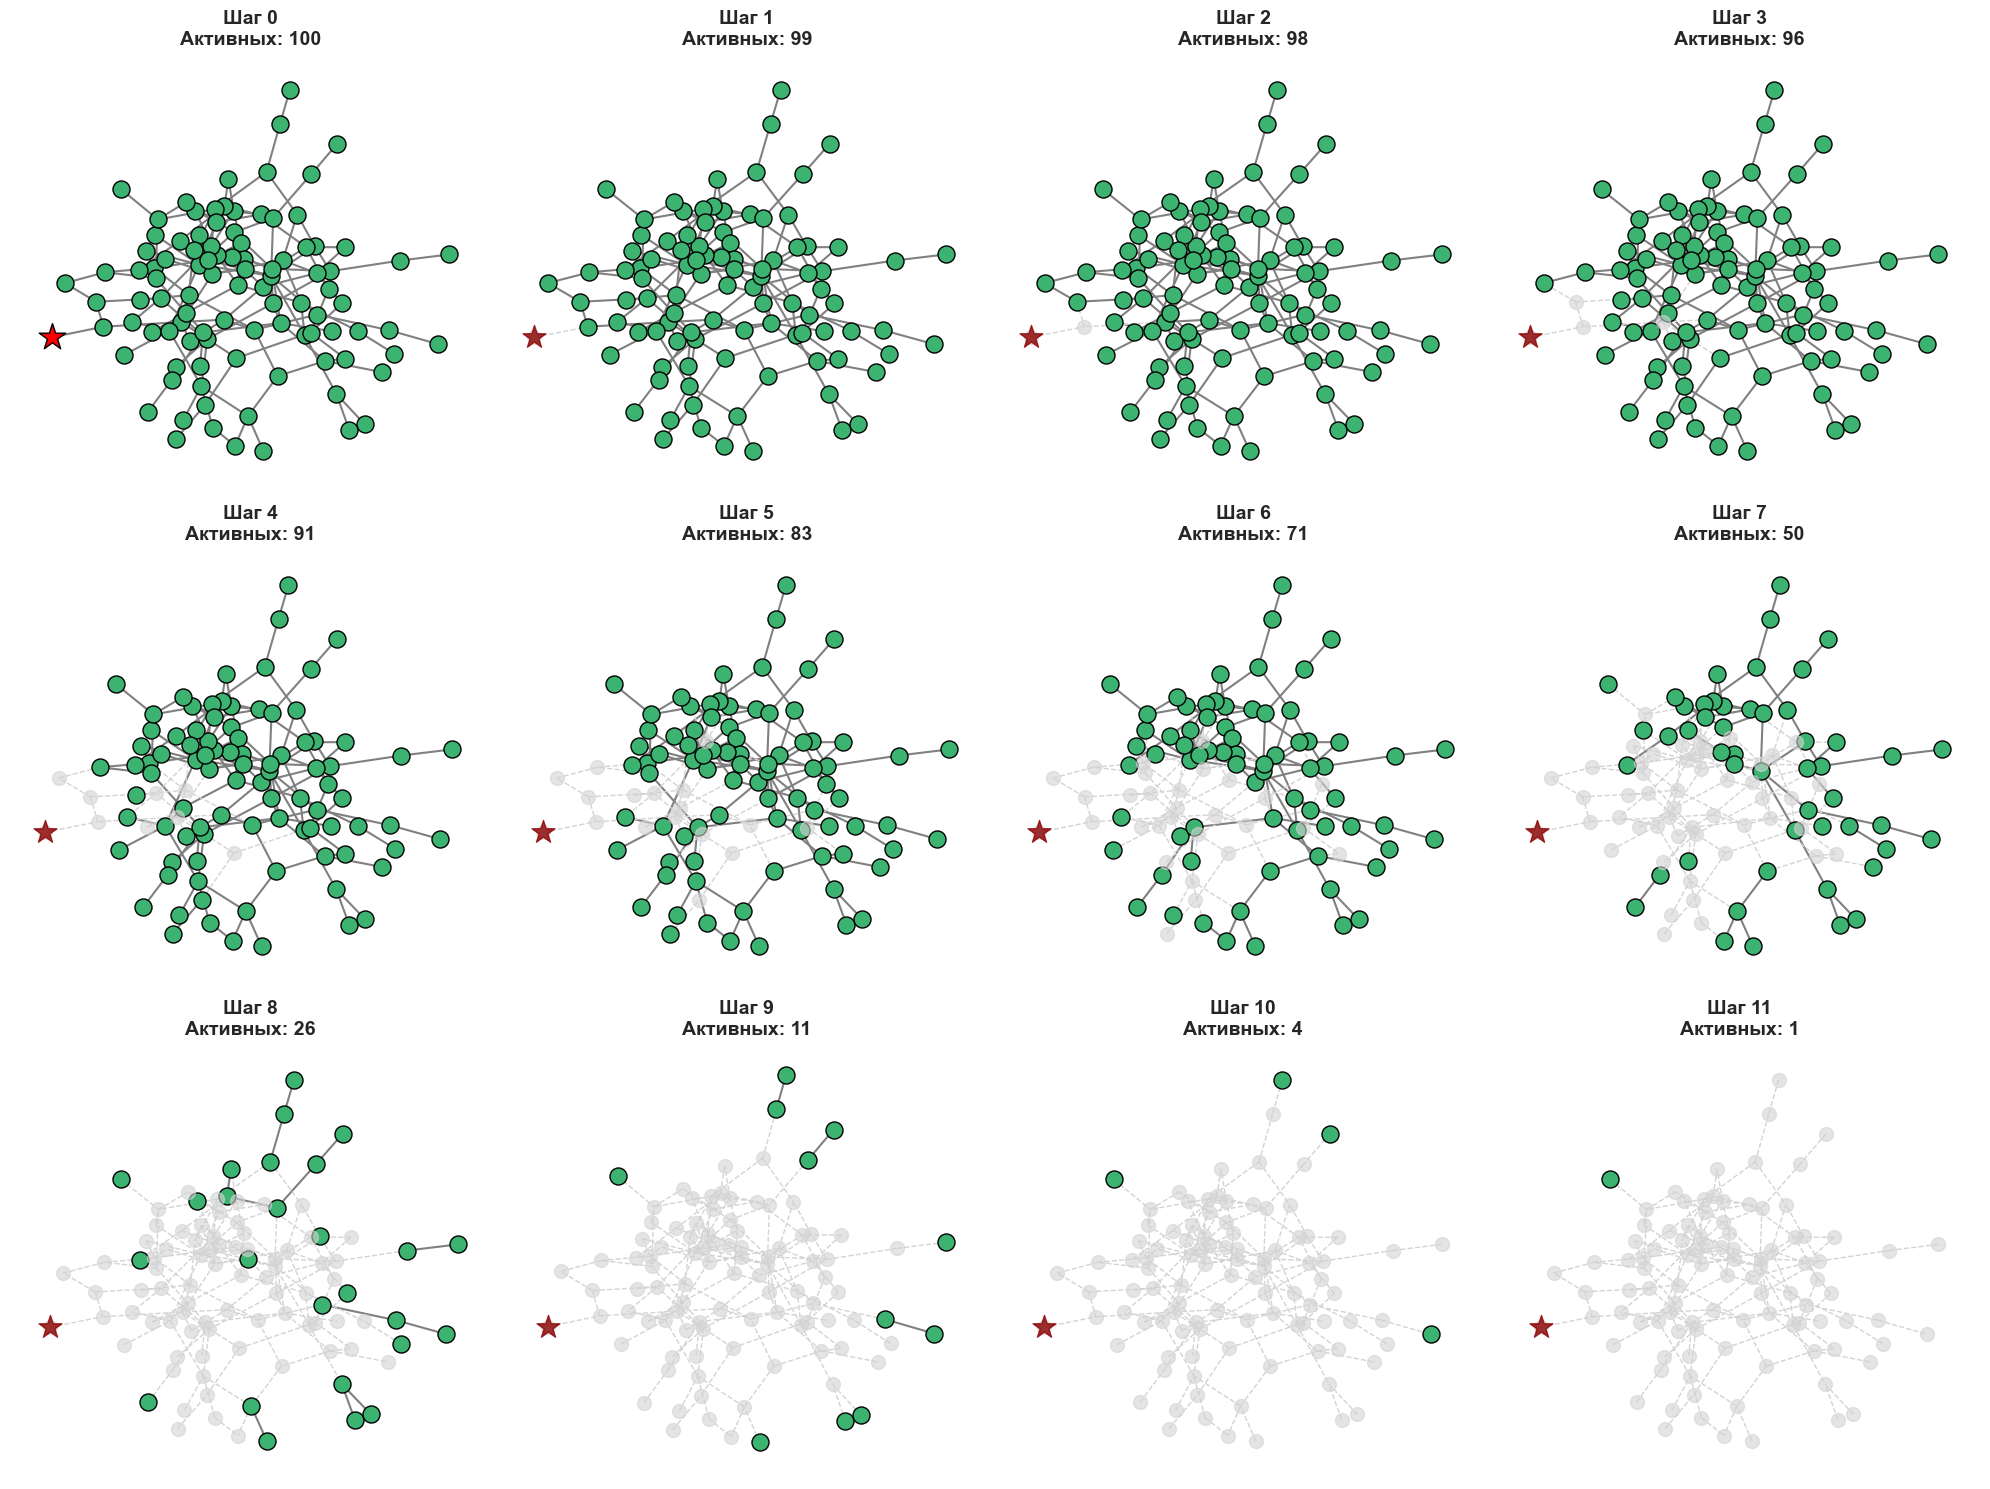


Визуализация для 3 эпицентров:


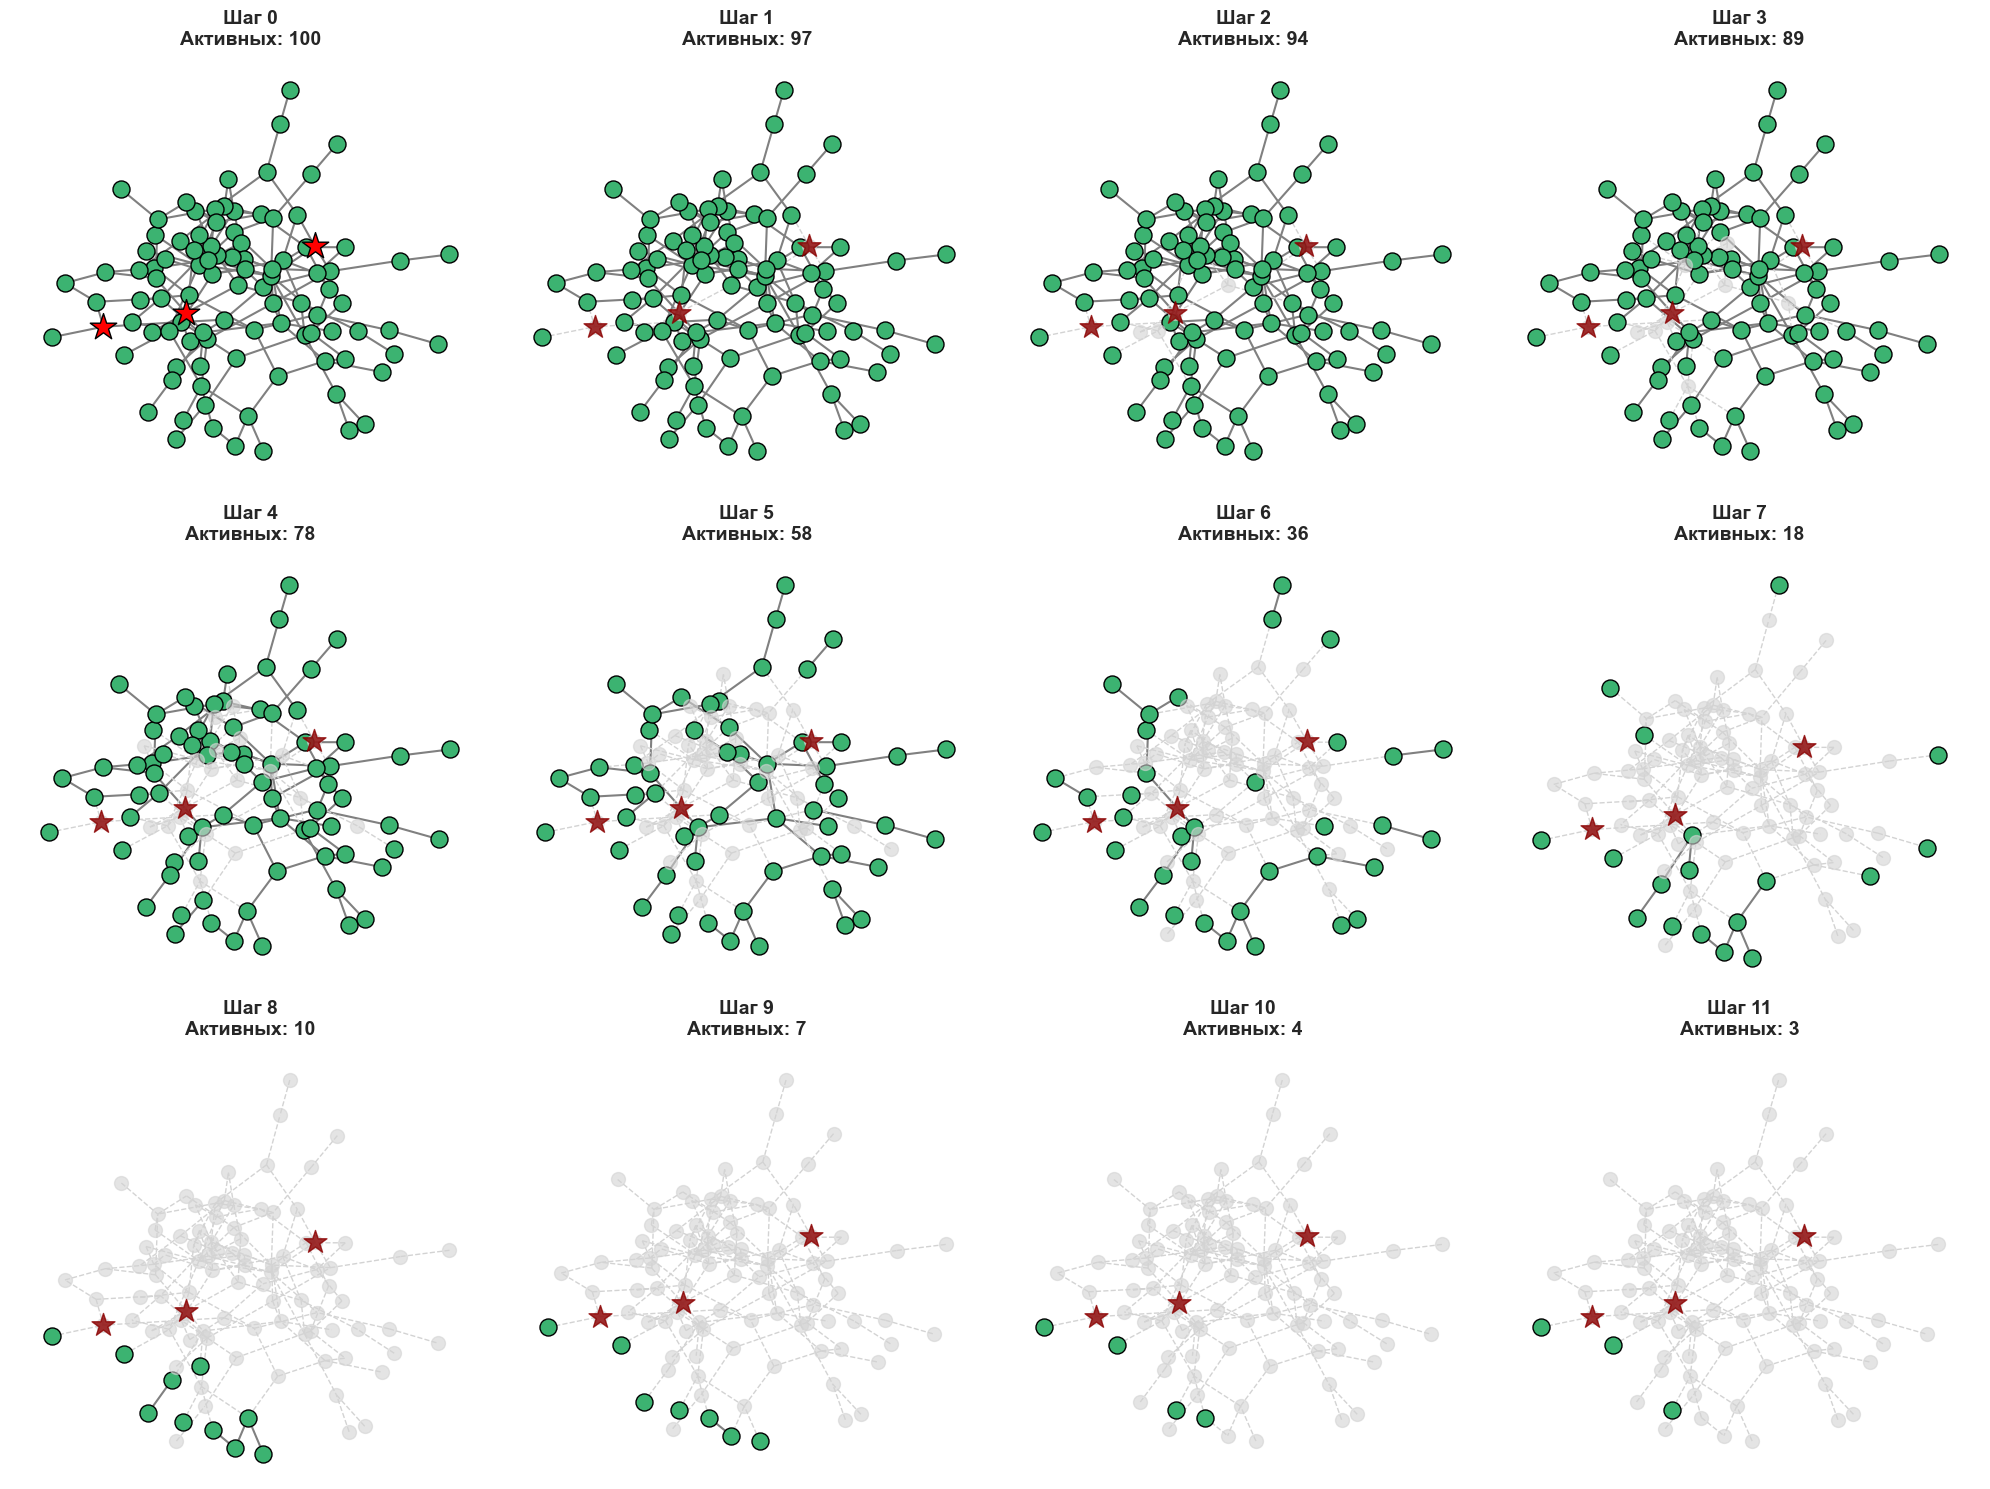

In [11]:
import math
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Set

class TrackedCascadeSimulator(CascadeSimulator):
    """
    Расширенный класс симулятора, который сохраняет 
    список активных узлов для визуализации.
    """
    def run_simulation(self, epicenters: List[int]) -> Dict:
        loads = self.base_loads.copy()
        active_nodes: Set[int] = set(self.G.nodes())
        
        for ep in epicenters:
            loads[ep] = self.capacity 
            
        # Теперь мы сохраняем множества узлов
        history_active_nodes =[set(active_nodes)] 
        step = 0
        
        while True:
            failing_nodes =[n for n in active_nodes if loads[n] >= self.capacity]
            if not failing_nodes:
                break
                
            step += 1
            for node in failing_nodes:
                active_neighbors =[
                    nbr for nbr in self.G.neighbors(node) 
                    if nbr in active_nodes and nbr not in failing_nodes
                ]
                if active_neighbors:
                    distributed_load = loads[node] / len(active_neighbors)
                    for nbr in active_neighbors:
                        loads[nbr] += distributed_load
                        
            for node in failing_nodes:
                active_nodes.remove(node)
                
            # Сохраняем слепок активных узлов на текущем шаге (t)
            history_active_nodes.append(set(active_nodes))

        return {
            "history_nodes": history_active_nodes,
            "total_steps": step
        }


def plot_cascade_dynamics(G: nx.Graph, history_nodes: List[Set[int]], epicenters: List[int]):
    """
    Создает сетку графиков (subplots), показывая состояние графа на каждом шаге.
    
    Args:
        G: Исходный граф.
        history_nodes: Список множеств активных узлов по шагам.
        epicenters: Список узлов-эпицентров.
    """
    n_steps = len(history_nodes)
    
    # Расчет размера сетки графиков (максимум 4 колонки)
    cols = min(n_steps, 4)
    rows = math.ceil(n_steps / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    if n_steps == 1:
        axes =[axes]
    else:
        axes = axes.flatten()
        
    # Замораживаем координаты узлов (force-directed layout)
    # Фиксируем seed, чтобы при повторных запусках граф не крутился
    pos = nx.spring_layout(G, seed=42)
    all_nodes = set(G.nodes())
    
    for t in range(len(axes)):
        ax = axes[t]
        ax.axis('off') # Отключаем оси координат для красоты
        
        if t >= n_steps:
            continue # Пустые графики в конце сетки, если шагов меньше
            
        active = history_nodes[t]
        dead = all_nodes - active
        
        # --- Отрисовка ребер ---
        # Обычные ребра (оба узла живы)
        active_edges =[(u, v) for u, v in G.edges() if u in active and v in active]
        # Мертвые ребра (хотя бы один узел разрушен)
        dead_edges =[(u, v) for u, v in G.edges() if u in dead or v in dead]
        
        nx.draw_networkx_edges(G, pos, edgelist=active_edges, ax=ax, width=1.5, edge_color='gray')
        nx.draw_networkx_edges(G, pos, edgelist=dead_edges, ax=ax, width=1.0, edge_color='lightgray', style='dashed')
        
        # --- Отрисовка узлов ---
        # 1. Живые узлы (Зеленые)
        nx.draw_networkx_nodes(G, pos, nodelist=list(active - set(epicenters)), 
                               ax=ax, node_color='mediumseagreen', node_size=150, edgecolors='black')
        
        # 2. Мертвые узлы (Серые)
        if dead:
            nx.draw_networkx_nodes(G, pos, nodelist=list(dead), 
                                   ax=ax, node_color='lightgray', node_size=100, alpha=0.6)
            
        # 3. Эпицентры 
        # Если эпицентр еще жив (например, на t=0) - он красный. Если мертв - темно-бордовый
        alive_epis = [ep for ep in epicenters if ep in active]
        dead_epis =[ep for ep in epicenters if ep in dead]
        
        if alive_epis:
            nx.draw_networkx_nodes(G, pos, nodelist=alive_epis, 
                                   ax=ax, node_color='red', node_shape='*', node_size=400, edgecolors='black')
        if dead_epis:
            nx.draw_networkx_nodes(G, pos, nodelist=dead_epis, 
                                   ax=ax, node_color='darkred', node_shape='*', node_size=300, alpha=0.8)
            
        ax.set_title(f"Шаг {t}\nАктивных: {len(active)}", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- Запуск визуализации ---
# Используем тот же граф и эпицентры из предыдущей симуляции
tracked_simulator = TrackedCascadeSimulator(100, 150)
# Забираем граф из предыдущего инстанса, чтобы топология была идентичной Ячейке 1
tracked_simulator.G = simulator.G 
tracked_simulator.base_loads = simulator.base_loads

print("Визуализация для 1 эпицентра:")
res_1_tracked = tracked_simulator.run_simulation(epicenter_1)
plot_cascade_dynamics(tracked_simulator.G, res_1_tracked['history_nodes'], epicenter_1)

print("\nВизуализация для 3 эпицентров:")
res_3_tracked = tracked_simulator.run_simulation(epicenters_3)
plot_cascade_dynamics(tracked_simulator.G, res_3_tracked['history_nodes'], epicenters_3)

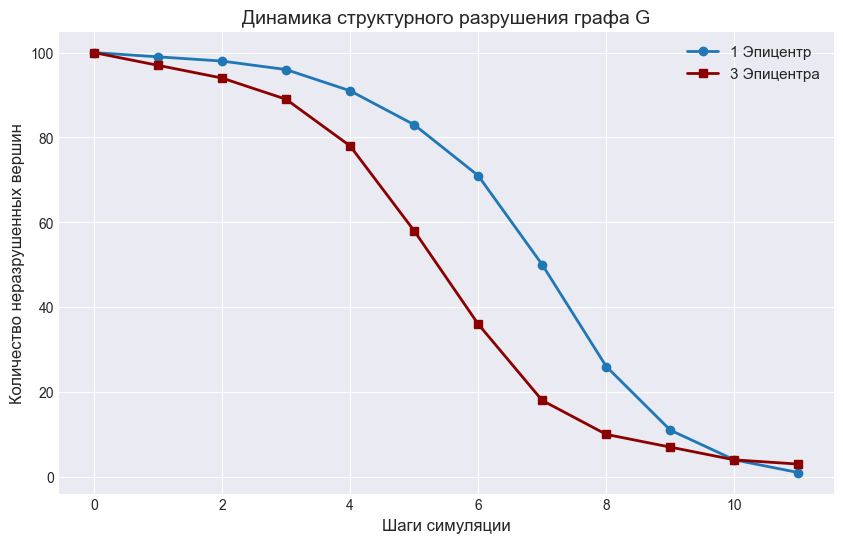

In [12]:
# [Ячейка 2: Визуализация]
def plot_degradation(res_1: Dict, res_3: Dict):
    """Строит графики деградации сети (Количество вершин от шага симуляции)."""
    plt.figure(figsize=(10, 6))
    
    # Ось X - шаги, Ось Y - количество выживших вершин
    steps_1 = range(len(res_1['history']))
    steps_3 = range(len(res_3['history']))
    
    plt.plot(steps_1, res_1['history'], marker='o', linewidth=2, label='1 Эпицентр')
    plt.plot(steps_3, res_3['history'], marker='s', linewidth=2, color='darkred', label='3 Эпицентра')
    
    # Отметки достижения критерия полного разрушения
    if res_1['destruction_step']:
        plt.axvline(x=res_1['destruction_step'], color='blue', linestyle='--', alpha=0.5, label='Полное разрушение (1 эпи)')
    if res_3['destruction_step']:
        plt.axvline(x=res_3['destruction_step'], color='red', linestyle='--', alpha=0.5, label='Полное разрушение (3 эпи)')

    plt.title('Динамика структурного разрушения графа G', fontsize=14)
    plt.xlabel('Шаги симуляции', fontsize=12)
    plt.ylabel('Количество неразрушенных вершин', fontsize=12)
    # plt.ylim(-2, 52)
    plt.legend(fontsize=11)
    plt.grid(True)
    plt.show()

plot_degradation(result_1_epi, result_3_epi)

Сравнивая результаты для 1 и 3 эпицентров, мы обычно наблюдаем следующие паттерны:

1. **Скорость разрушения (Velocity of cascade):** При запуске с 3 эпицентров градиент деградации сети (наклон кривой на графике) значительно круче. Вливание критической массы перегрузки сразу с трех точек приводит к экспоненциальному росту нагрузки на соседние узлы.
2. **Критерий связности:** При 3 эпицентрах граф гораздо быстрее распадается на несвязные компоненты (иногда на самом первом шаге, если эпицентры удачно/неудачно расположены как *мосты* — *bridges*).
3. **Выживаемость:** Каскад от 1 узла может затухнуть из-за топологии графа (нагрузка рассеивается по множеству узлов с высокой степенью (Degree Hubs), и их значение не достигает предела 10). Но 3 эпицентра почти всегда гарантируют **Global Cascade**, ведущий к полному коллапсу сети (0 вершин), так как изначальная средняя нагрузка (5-9) уже близка к пределу (10).